In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
#from NN_utils import load_vstate

#from correlations import correlations_vstate


jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
jax.devices()

[CudaDevice(id=0)]

In [15]:
def circulant(
    row: npt.ArrayLike, times: Optional[int] = None
) -> npt.ArrayLike:
    """Build a (full or partial) circulant matrix based on an array.

    Args:
        row: The first row of the matrix.
        times: If not None, the number of rows to generate.

    Returns:
        If `times` is None, a square matrix with all the offset versions of the
        first argument. Otherwise, `times` rows of a circulant matrix.
    """
    row = jnp.asarray(row)

    def scan_arg(carry, _):
        new_carry = jnp.roll(carry, -1)
        return (new_carry, new_carry)

    if times is None:
        nruter = jax.lax.scan(scan_arg, row, row)[1][::-1, :]
    else:
        nruter = jax.lax.scan(scan_arg, row, None, length=times)[1][::-1, :]

    return nruter

In [28]:
a=jnp.array([[i for i in range(0, 4)]]*3)
a= a.reshape(-1, 2,2)
a, jnp.roll(a, -1, axis=-2)

(Array([[[0, 1],
         [2, 3]],
 
        [[0, 1],
         [2, 3]],
 
        [[0, 1],
         [2, 3]]], dtype=int64),
 Array([[[2, 3],
         [0, 1]],
 
        [[2, 3],
         [0, 1]],
 
        [[2, 3],
         [0, 1]]], dtype=int64))

In [ ]:

def traslations_2D_vmap(
    x: npt.ArrayLike, 
    token_size: Tuple[int, int]
) -> npt.ArrayLike:
        """
        Returns a matrix of translations of a flat input vector x 
        which represtents a 2D lattice state. 
        Enhances time execution. 
        """
        # Convertir a tensor de orden 3 y jugar con el eje 1 y 2
        x = x.reshape(size)
        idx = jnp.unravel_index(jnp.arange(size[0]*size[1]), size)
        shift_idx = jnp.array(idx).T
        
        roll= lambda x, shift: jnp.roll(x, shift=shift, axis=(0,1)).flatten()
        
        return jax.vmap(roll,in_axes=(None,0))(x, shift_idx)

 

def traslations_2D_scan(x, size):

    """
    Returns a matrix of translations of a flat input vector x 
    which represtents a 2D lattice state. 
    Enhances memory saving. 
    """

    x = x.reshape(size)

    iter_x = jnp.arange(size[0])
    iter_y = jnp.arange(size[1])

    def scan_and_roll_x(carry_x, _):
        x = jnp.roll(carry_x, shift=-1, axis=0)
        
        def scan_and_roll_y(carry_y, _):
            y = jnp.roll(carry_y, shift=-1, axis=1)
            return y, y.flatten()
        
        _, block_y = jax.lax.scan(scan_and_roll_y, x, iter_y)
        return x, block_y
    
    return jax.lax.scan(scan_and_roll_x, x, iter_x)[1].reshape(-1, size[0]*size[1])


size = (3,3)
input= jnp.arange(np.prod(size)).astype(jnp.float64)

a= wrap(size)(input)
b = traslations_2D_scan(input, size)

print(f"{a}\n\n{b}")
a=np.array(a)
b=np.array(b)
[i in b for i in a]


[[0. 1. 2. 3. 4. 5. 6. 7. 8.]
 [2. 0. 1. 5. 3. 4. 8. 6. 7.]
 [1. 2. 0. 4. 5. 3. 7. 8. 6.]
 [6. 7. 8. 0. 1. 2. 3. 4. 5.]
 [8. 6. 7. 2. 0. 1. 5. 3. 4.]
 [7. 8. 6. 1. 2. 0. 4. 5. 3.]
 [3. 4. 5. 6. 7. 8. 0. 1. 2.]
 [5. 3. 4. 8. 6. 7. 2. 0. 1.]
 [4. 5. 3. 7. 8. 6. 1. 2. 0.]]

[[4. 5. 3. 7. 8. 6. 1. 2. 0.]
 [5. 3. 4. 8. 6. 7. 2. 0. 1.]
 [3. 4. 5. 6. 7. 8. 0. 1. 2.]
 [7. 8. 6. 1. 2. 0. 4. 5. 3.]
 [8. 6. 7. 2. 0. 1. 5. 3. 4.]
 [6. 7. 8. 0. 1. 2. 3. 4. 5.]
 [1. 2. 0. 4. 5. 3. 7. 8. 6.]
 [2. 0. 1. 5. 3. 4. 8. 6. 7.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8.]]


[True, True, True, True, True, True, True, True, True]

In [ ]:
[i in b for i in a]

Array([  0,  -1,  -2,  -3,  -4,  -5,  -6,  -7,  -8,  -9, -10, -11, -12,
       -13, -14, -15], dtype=int64)

In [4]:
def random(size: Tuple[int, int], key: jax.random.PRNGKey) -> npt.NDArray:
    """
    Generates a random 2D array of given size.
    """

    return jax.random.uniform(key, shape=(jnp.prod(np.array(size)),), minval=0.0, maxval=1.0, dtype=jnp.float64)

rng_key=jax.random.PRNGKey(666)

traslations_2D_scan_jit = jax.jit(traslations_2D_scan, static_argnames='size')

%timeit -n 2000 -r 50  traslations_2D_scan_jit(random(size, rng_key), size) 

234 μs ± 5.81 μs per loop (mean ± std. dev. of 50 runs, 2,000 loops each)


In [5]:
wrap_jit = jax.jit(wrap(size))
%timeit -n 2000 -r 50 wrap_jit(random(size, rng_key))

150 μs ± 9.69 μs per loop (mean ± std. dev. of 50 runs, 2,000 loops each)


In [ ]:


fun_jit=jax.jit(traslations_2D_vmap, static_argnames=['size'])
fun_jit(input,size)

#translations = jax.jit(traslations_2D_vmap,static_argnames=['size'])(input,size)
%timeit -n 100000 -r 20 fun_jit(input,size)


11.7 μs ± 243 ns per loop (mean ± std. dev. of 20 runs, 100,000 loops each)


[3.0,
 0.550543802217391,
 0.6073644094498059,
 0.5640711070776137,
 0.7942245016539735,
 0.609195041746485,
 0.6491520761975109,
 0.6085002598969915,
 0.9056906127740467,
 0.6678848164100643,
 0.6517023493928257,
 0.6187051838071691,
 0.7863987597363395,
 0.6018317643987728,
 0.5990621856550524,
 0.5234495588418444,
 3.0,
 0.5452279923668515,
 0.5878816615302292,
 0.5907000574610834,
 0.7382239909858317,
 0.646925365889541,
 0.6014777685426423,
 0.5627089021611951,
 0.9001583114029869,
 0.598007311163071,
 0.568403651761487,
 0.5602235932289789,
 0.7533827801198063,
 0.5761319430487689,
 0.555642120956835,
 3.0,
 0.4803858834916138,
 0.5913397459098921,
 0.5218541697615278,
 0.733830967600206,
 0.5743328317378958,
 0.6312460974413191,
 0.5917984232621079,
 0.9030118443899684,
 0.4438717253390692,
 0.5579085352900807,
 0.5748722607423256,
 0.8031430119973799,
 0.48628761559135336,
 3.0,
 0.6257818084522445,
 0.6042651105875385,
 0.5590261699819151,
 0.8238106121102141,
 0.5201122580081

In [14]:
vstate.hilbert.size

16

In [ ]:
from VA_project.model.model import OxalateJKGamma
from VA_project.engine.runners import Runner
import netket as nk

settings={
    
    'size': (4,4), #Lattice size
    'alpha':2.5,

    'NN_arch': {

        'MLP': {

            'rng' : jax.random.PRNGKey(0),
            'layers' : ['dense', 'activation', 'dense'],
            'dimensions' : [128, 128],
            'activation' : [nn.sigmoid],
            'dropout' : [],

        }

    },
    'optimizer': {
        'adam': {
            'learning_rate': 0.01
        },
        'Sgd': {
            'learning_rate': 0.01
        },
        'AdaGrad': {
            'learning_rate': 0.01
        },
    },   

    'sampler': {
        'type': 'MetropolisLocal',
        'n_samples': 1008,
        
    },
}




In [ ]:
class MLP(nn.Module):
    """A simple multi-layer perceptron."""
    
    param_dtype : Any = jnp.complex64
    hidden_dims: int | Tuple[int, ...] = None
    activation: Callable | Tuple[Callable, ...] = None

    def setup(self):
        assert self.hidden_dims is not None, "Hidden_dims must be provided."

        if self.activation is None:
            self.activation = tuple([0] * len(self.hidden_dims))
        else:
            if len(self.hidden_dims) != len(self.activation):
                raise ValueError("The number of hidden dimensions must match the number of activation functions,"
                                 f" but got {len(self.hidden_dims)} and {len(self.activation)} respectively.")
        
    @nn.compact
    def __call__(self, x):
        
        for hi, act in zip(self.hidden_dims, self.activation):
            x = nn.Dense(hi, param_dtype=self.param_dtype)(x)
            if act:
                x = act(x)

        return x.squeeze(-1)
    


In [ ]:
strength = 0.2
theta = 9.0
phi = 72.

diag_shift= 0.001
n_iter=1000


act_dict={
    'sigmoid': nn.sigmoid,
    'tanh': nn.tanh,
    'softmax': nn.softmax,
    'gelu': nn.gelu,}

opt_name_dict={
    'Sgd': nk.optimizer.Sgd,
    'adam': nk.optimizer.Adam,
    'AdaGrad': nk.optimizer.AdaGrad,} 

opt_name_list = ['Sgd', 'adam', 'AdaGrad']
learning_rate_list = [0.1, 0.01, 0.001]

dimensions_list = [
    (16,16,1),
    (32,32,1),
    (64,64,1),
    (16,32,64,64,32,16,1),
]
activation_list = [
    [('softmax',0,0),(0,'softmax',0),('tanh',0,0),(0,'tanh',0),('gelu',0,0),(0,'gelu',0)],
    [('softmax',0,0),(0,'softmax',0),('tanh',0,0),(0,'tanh',0),('gelu',0,0),(0,'gelu',0)],
    [('softmax',0,0),(0,'softmax',0),('tanh',0,0),(0,'tanh',0),('gelu',0,0),(0,'gelu',0)],
    [('softmax',0,0,'softmax',0,'softmax',0),('tanh',0,0,'tanh',0,'tanh',0),('gelu',0,0,'gelu',0,'gelu',0), ('gelu',0,0,'sigmoide',0,'tanh',0)]
]


d=0 ; a=0 

for d, dimensions in enumerate(dimensions_list): 
    
    for a, activation_name in enumerate(activation_list[d]):

        activation = tuple([act_dict[act] if act != 0 else 0 for act in activation_name])

        for opt_name in opt_name_list:

            for learning_rate in learning_rate_list:

                print(f"dimensions: {dimensions} \nactivation: {activation_name} \nopt_name: {opt_name} \nlearning_rate: {learning_rate}")

                time_in = time.time()
                
                # Initialize the model
                model = MLP(
                    param_dtype=jnp.complex64,
                    hidden_dims=dimensions,
                    activation=activation,
                    )
                # ...with rng keys 
                rng= jax.random.PRNGKey(0)
                key1, key2 = jax.random.split(rng)
                keys = {'params': key1, 'dropout': key2}

                params = model.init(keys['params'], jnp.ones((4*4), dtype=jnp.complex64)) 
                output=model.apply(params, jnp.ones((4*4), dtype=jnp.complex64))

                hi = nk.hilbert.Spin(s=0.5, N = int(np.prod(settings['size'])))

                sampler = nk.sampler.MetropolisLocal(hi, dtype=complex)
                #print(sampler.sample_next(NN_arch, model_params))

                optimizer = opt_name_dict[opt_name](learning_rate=learning_rate)

                vstate = nk.vqs.MCState(sampler, model, n_samples = settings['sampler']['n_samples'])
                is_holo = nk.utils.is_probably_holomorphic(vstate._apply_fun, vstate.parameters, vstate.samples, vstate.model_state)

                SR= nk.optimizer.SR(diag_shift = diag_shift, holomorphic = True)

                # Create the Hamiltonian
                oxa=OxalateJKGamma(settings['size'], 
                                [strength, theta, phi],
                                    bc='periodic', order='default_2')
                H = Runner(oxa.cm).build_hamiltonian()

                gs = nk.VMC(
                    hamiltonian=H,
                    optimizer=optimizer,
                    preconditioner=SR,
                    variational_state=vstate)
                log = nk.logging.RuntimeLog()
                keeper= BestIterKeeper(H, np.prod(settings['size']), baseline = 1e-8,
                    #filename=pathlib.Path("best_state.nk"),
                )
                gs.run(n_iter=n_iter, out=log, callback= [keeper.update])
                time_out = time.time()
                time_exe= time_out - time_in

                # Extract some results
                E_hist = np.array(log['Energy']['Mean']).real
                dev_E_hist = np.array(log['Energy']['Sigma']).real
                E_gr = Runner(oxa.cm).exact_energy_lanczos()

                # Calculate the variance score
                var= np.array(log['Energy']['Variance']).real
                vscore = int(np.prod(settings['size']))*var//(E_hist**2)
                error=np.abs(E_hist-E_gr)/np.abs(E_gr)

                print(f"E_hist: {len(E_hist)}")
                print(f"dev_E_hist: {len(dev_E_hist)}")
                print(f"vscore: {len(vscore)}")
                print(f"error: {len(error)}")

                # Plotting

                set_dim=[f"D({dim})" for dim in dimensions]
                set_act=[f"A({act})" for act in activation_name]
                setup='||'
                for i in range(len(dimensions)):
                    setup+=f" {set_dim[i]} |"
                    setup+=f" {set_act[i]} |" if '0' not in set_act[i] else ''
                    
                setup+="|"
                setup_sim = f"opt: {opt_name} \nl_rate: {learning_rate} \ntime_exe: {time_exe}"

                fig, ax = plt.subplots(3,1,figsize=(8, 18))
                ax[0].set_title(f"Convergence 4x4 theta=9 phi=72")
                ax[0].errorbar(range(len(E_hist)), E_hist, yerr=dev_E_hist, fmt='none', ecolor='r', label='E_stdev')
                ax[0].plot(E_hist, color='blue', label='E') 
                ax[0].hlines(E_gr,0,n_iter, color='green', label='ED Energy')
                ax[0].text(0.45, 0.93, setup, transform=ax[0].transAxes, fontsize=12, color='k', ha='center', va='center',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                ax[0].text(0.9, 0.75, setup_sim, transform=ax[0].transAxes, fontsize=10, color='k', ha='center', va='center',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

                ax[0].legend()
                ax[0].set_xlabel('Iteration')
                ax[0].set_ylabel('Energy', fontsize=12)
                ax[0].grid()

                ax[1].plot(error, color='red', label='E')
                ax[1].set_yscale('log')
                ax[1].legend()
                ax[1].set_xlabel('Iteration')
                ax[1].set_ylabel('Error', fontsize=12)
                ax[1].grid()


                ax[2].plot(vscore, color='purple', label='Vscore')
                ax[2].set_yscale('log')
                ax[2].legend()
                ax[2].set_xlabel('Iteration')
                ax[2].set_ylabel('Vscore', fontsize=12)
                ax[2].grid()
                plt.tight_layout()
                plt.savefig(f"Figures/First_sim/4x4_theta9_phi72_d{d}_a{a}_{opt_name}_lr_{learning_rate}.jpeg", dpi=600)

In [56]:
opt_name = 'AdaGrad'
learning_rate_list = [0.1]

dimensions = (32,32,1)
activation= ('softmax',0,0)

act_dict={
    'sigmoid': nn.sigmoid,
    'tanh': nn.tanh,
    'softmax': nn.softmax,
    'gelu': nn.gelu
}

opt_name_dict={
    'Sgd': nk.optimizer.Sgd,
    'adam': nk.optimizer.Adam,
    'AdaGrad': nk.optimizer.AdaGrad
} 


activation = tuple([act_dict[act] if act != 0 else 0 for act in activation])

In [57]:
# Initialize the model
model = MLP(
    param_dtype=jnp.complex64,
    hidden_dims=dimensions,
    activation=activation,
    )
# ...with rng keys 
rng= jax.random.PRNGKey(0)
key1, key2 = jax.random.split(rng)
keys = {'params': key1, 'dropout': key2}

params = model.init(keys['params'], jnp.ones((4*4), dtype=jnp.complex64)) 
output=model.apply(params, jnp.ones((4*4), dtype=jnp.complex64))

hi = nk.hilbert.Spin(s=0.5, N = int(np.prod(settings['size'])))

sampler = nk.sampler.MetropolisHamiltonian(hi, hamiltonian= H, dtype=complex)
#print(sampler.sample_next(NN_arch, model_params))

optimizer = opt_name_dict[opt_name](learning_rate=learning_rate)

vstate = nk.vqs.MCState(sampler, model, n_samples = settings['sampler']['n_samples'])
is_holo = nk.utils.is_probably_holomorphic(vstate._apply_fun, vstate.parameters, vstate.samples, vstate.model_state)

SR= nk.optimizer.SR(diag_shift = diag_shift, holomorphic = True)

# Create the Hamiltonian
oxa=OxalateJKGamma(settings['size'], 
                [strength, theta, phi],
                    bc='periodic', order='default_2')
H = Runner(oxa.cm).build_hamiltonian()

gs = nk.VMC(
    hamiltonian=H,
    optimizer=optimizer,
    preconditioner=SR,
    variational_state=vstate)
log = nk.logging.RuntimeLog()
keeper= BestIterKeeper(H, np.prod(settings['size']), baseline = 1e-8,
    #filename=pathlib.Path("best_state.nk"),
)
gs.run(n_iter=n_iter, out=log, callback= [keeper.update])

  0%|          | 0/1000 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [ ]:
vstate.sampler_state.rng

MetropolisSamplerState(# accepted = 11989/17408 (68.87063419117648%), rng state=[2420705905 3383911012])

In [104]:
model.apply(keeper.best_state.parameters, keeper.best_state.samples)

ScopeCollectionNotFound: Tried to access "kernel" from collection "params" in "/Dense_0" but the collection is empty. (https://flax.readthedocs.io/en/latest/api_reference/flax.errors.html#flax.errors.ScopeCollectionNotFound)

/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_AdaGrad_lr_0.001.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_adam_lr_0.01.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_adam_lr_0.1.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_Sgd_lr_0.1.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_AdaGrad_lr_0.1.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_adam_lr_0.001.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_AdaGrad_lr_0.01.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_Sgd_lr_0.001.jpeg
/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/4x4_theta9_phi72_d0_a1_Sgd_lr_0.01.jpeg


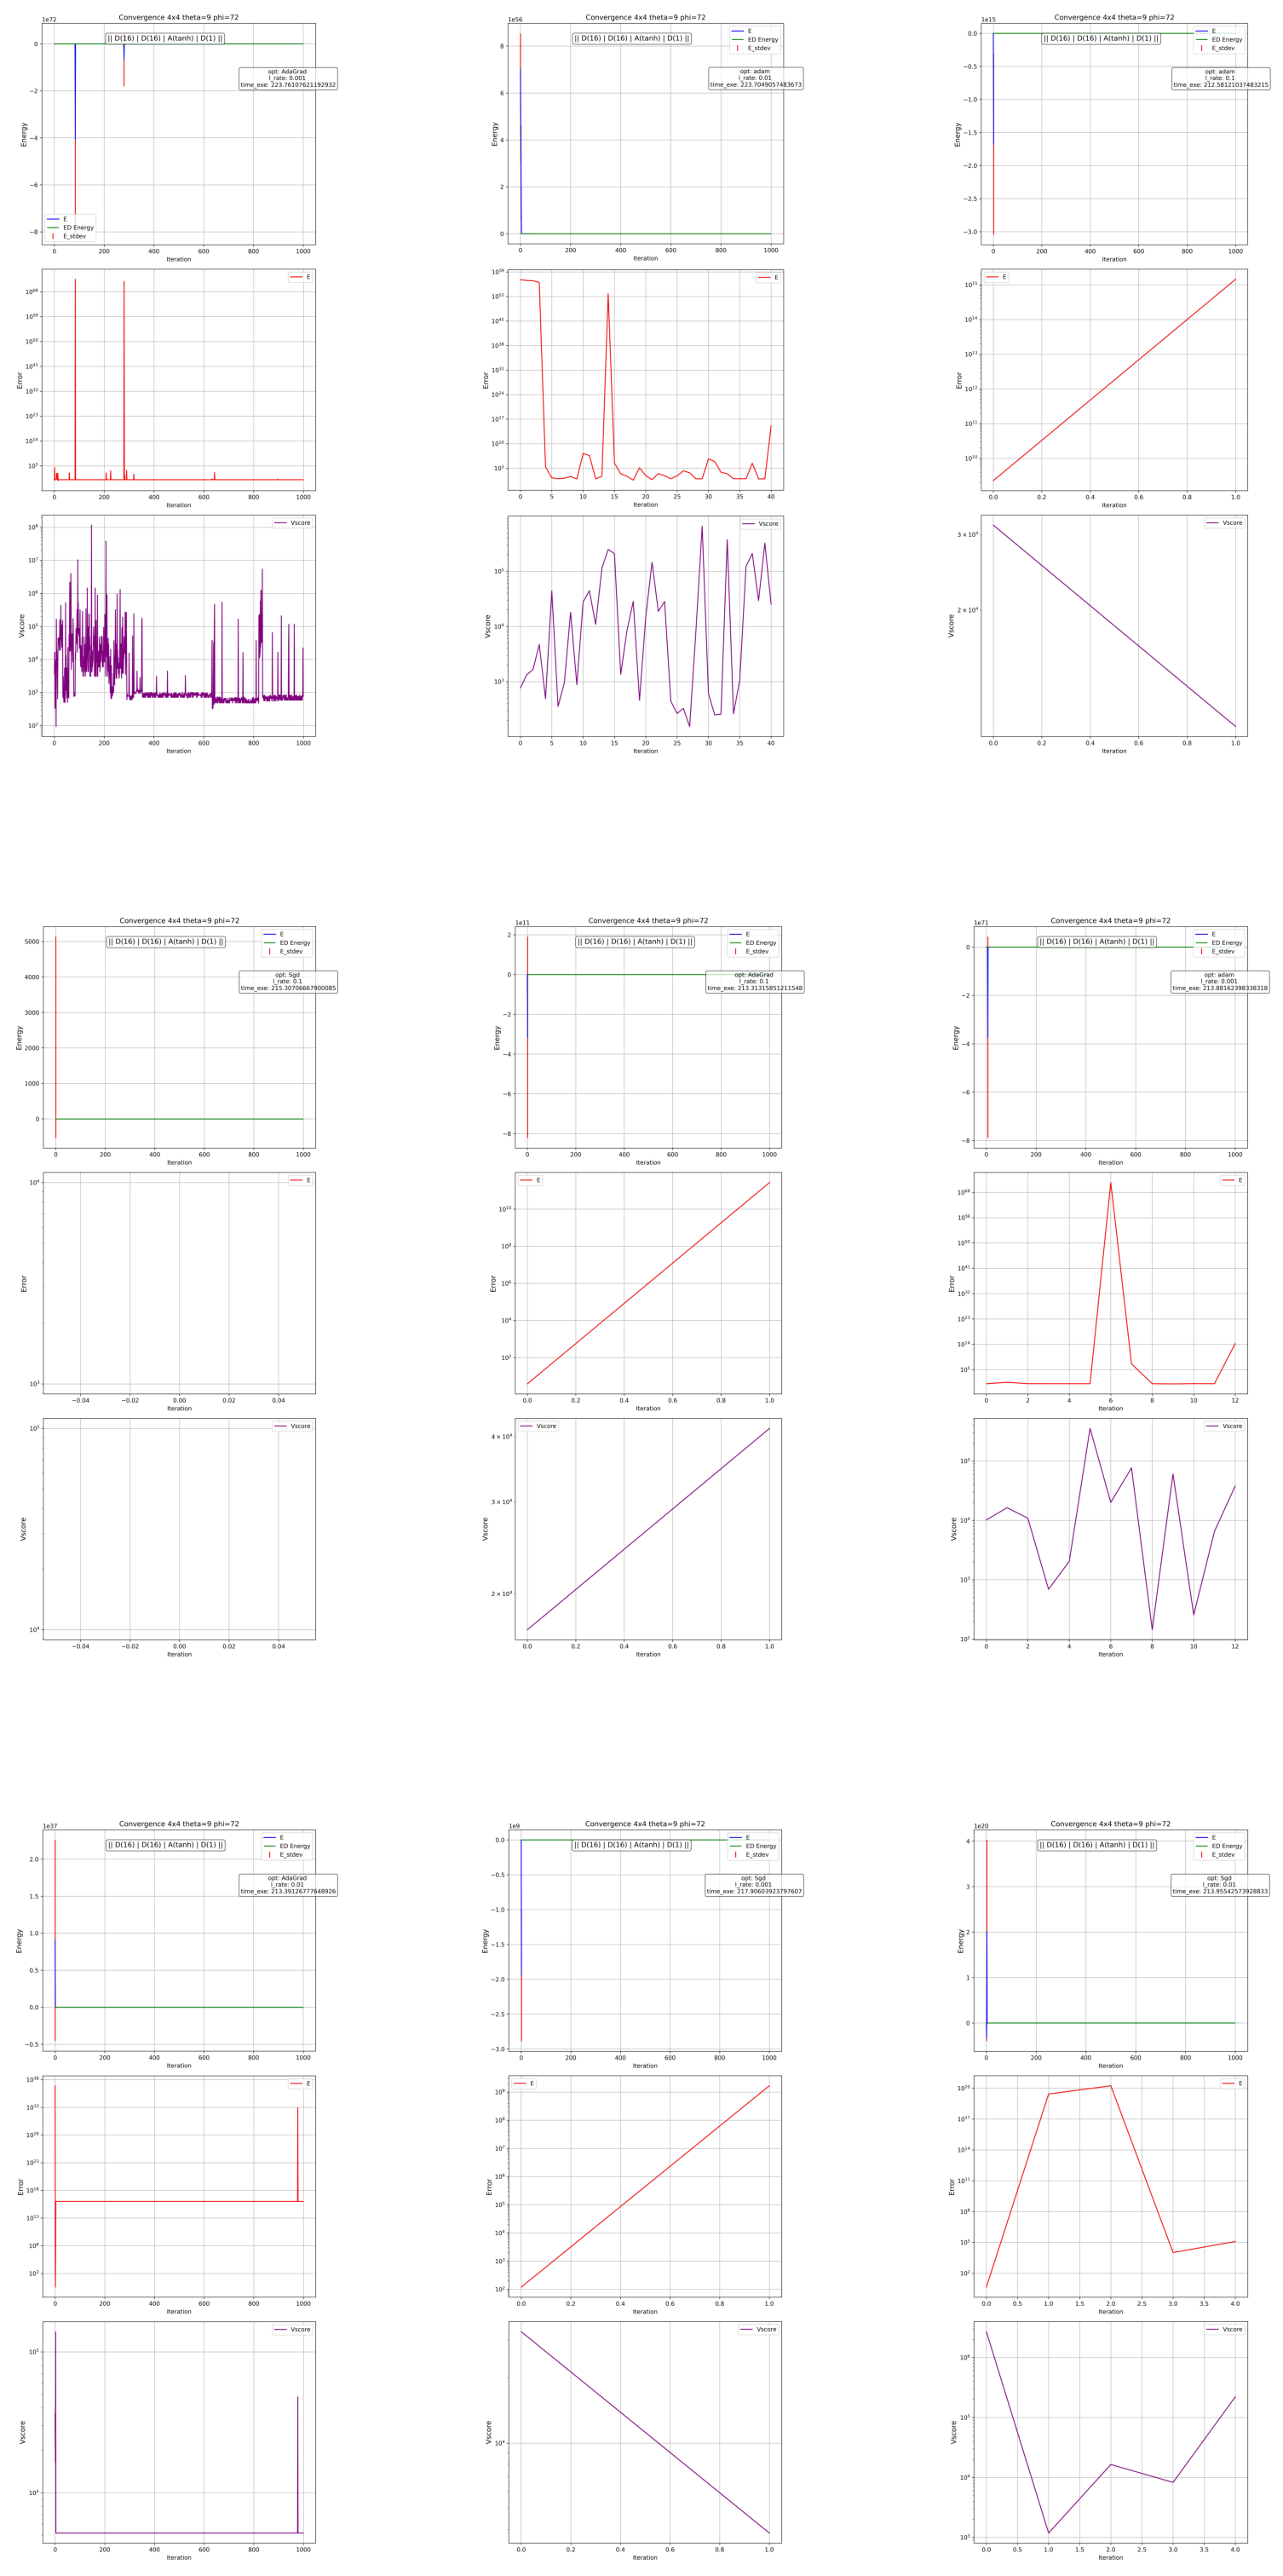

<Figure size 640x480 with 0 Axes>

In [42]:
import glob
from PIL import Image
folder = "/home/ihuarte/Escritorio/Ivan/NNs/Figures/First_sim/"

d=0
a=1
opt_name = 'Sgd'
learning_rate = 0.01

dim=f"*d{d}"
act=f"*a{a}"
opt=f"*{opt_name}"
lr=f"*{learning_rate}"
all = f"*{dim}*{act}*{opt}*{lr}"

filtro = dim + act 
files = glob.glob(folder + filtro +'*')


rows = len(files)//3 + len(files) % 3
fig,ax=plt.subplots(rows,3, figsize=(20, 13*rows))
ax=ax.flatten()
for i, file in enumerate(files):
    print(file)

    
    img = Image.open(file)
    ax[i].imshow(img)
    ax[i].axis('off')

if len(files) % 3 == 1:
    ax[-1].axis('off')
    ax[-1].axis('off')
if len(files) % 3 == 2:
    ax[-1].axis('off')

plt.axis('off')
plt.show()
plt.tight_layout()

In [83]:
-1.08/16

-0.0675